<a href="https://colab.research.google.com/github/Abhi0129n/Machine-learning-/blob/main/titanic%20dataset%20naive%20bayes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
# ==========================================
# Experiment 2: Naive Bayes Classifier
# Titanic Dataset
# ==========================================

# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [12]:
# Load Dataset

df = pd.read_csv("/content/train_and_test2.csv")

df.head()

,Passengerid,Age,Fare,Sex,sibsp,zero,zero.1,zero.2,zero.3,zero.4,...,zero.12,zero.13,zero.14,Pclass,zero.15,zero.16,Embarked,zero.17,zero.18,2urvived
0,1,22.0,7.2500,0,1,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0
1,2,38.0,71.2833,1,1,0,0,0,0,0,...,0,0,0,1,0,0,0.0,0,0,1
2,3,26.0,7.9250,1,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,1
3,4,35.0,53.1000,1,1,0,0,0,0,0,...,0,0,0,1,0,0,2.0,0,0,1
4,5,35.0,8.0500,0,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0


In [13]:
# Dataset Information

print(df.shape)

df.info()

(1309, 28)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 28 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Passengerid  1309 non-null   int64  
 1   Age          1309 non-null   float64
 2   Fare         1309 non-null   float64
 3   Sex          1309 non-null   int64  
 4   sibsp        1309 non-null   int64  
 5   zero         1309 non-null   int64  
 6   zero.1       1309 non-null   int64  
 7   zero.2       1309 non-null   int64  
 8   zero.3       1309 non-null   int64  
 9   zero.4       1309 non-null   int64  
 10  zero.5       1309 non-null   int64  
 11  zero.6       1309 non-null   int64  
 12  Parch        1309 non-null   int64  
 13  zero.7       1309 non-null   int64  
 14  zero.8       1309 non-null   int64  
 15  zero.9       1309 non-null   int64  
 16  zero.10      1309 non-null   int64  
 17  zero.11      1309 non-null   int64  
 18  zero.12      1309 non-null   int64  


In [14]:
# Rename Target Column

df.rename(columns={"2urvived":"Survived"}, inplace=True)

In [15]:
# Remove Unnecessary Columns

zero_columns = [col for col in df.columns if "zero" in col.lower()]

df.drop(columns=zero_columns, inplace=True)

df.head()

,Passengerid,Age,Fare,Sex,sibsp,Parch,Pclass,Embarked,Survived
0,1,22.0,7.2500,0,1,0,3,2.0,0
1,2,38.0,71.2833,1,1,0,1,0.0,1
2,3,26.0,7.9250,1,0,0,3,2.0,1
3,4,35.0,53.1000,1,1,0,1,2.0,1
4,5,35.0,8.0500,0,0,0,3,2.0,0


In [16]:
# Check Missing Values

print(df.isnull().sum())

Passengerid    0
Age            0
Fare           0
Sex            0
sibsp          0
Parch          0
Pclass         0
Embarked       2
Survived       0
dtype: int64


In [18]:
# Fill Missing Values

df["Embarked"].fillna(df["Embarked"].mode()[0], inplace=True)

df["Age"].fillna(df["Age"].median(), inplace=True)
print(df.isnull().sum())

Passengerid    0
Age            0
Fare           0
Sex            0
sibsp          0
Parch          0
Pclass         0
Embarked       0
Survived       0
dtype: int64


/tmp/ipykernel_595/3099784550.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Embarked"].fillna(df["Embarked"].mode()[0], inplace=True)
/tmp/ipykernel_595/3099784550.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=T

In [19]:
# Final Dataset

print(df.head())

print(df.columns)

   Passengerid   Age     Fare  Sex  sibsp  Parch  Pclass  Embarked  Survived
0            1  22.0   7.2500    0      1      0       3       2.0         0
1            2  38.0  71.2833    1      1      0       1       0.0         1
2            3  26.0   7.9250    1      0      0       3       2.0         1
3            4  35.0  53.1000    1      1      0       1       2.0         1
4            5  35.0   8.0500    0      0      0       3       2.0         0
Index(['Passengerid', 'Age', 'Fare', 'Sex', 'sibsp', 'Parch', 'Pclass',
       'Embarked', 'Survived'],
      dtype='object')


In [20]:
# Separate Features and Target

X = df.drop("Survived", axis=1)

y = df["Survived"]

In [21]:
# Split Dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data :", X_train.shape)

print("Testing Data :", X_test.shape)

Training Data : (1047, 8)
Testing Data : (262, 8)


In [22]:
# Train Gaussian Naive Bayes

model = GaussianNB()

model.fit(X_train, y_train)

print("Model Trained Successfully")

Model Trained Successfully


In [23]:
# Prediction

y_pred = model.predict(X_test)

print(y_pred[:10])

[0 0 0 0 0 1 0 1 0 0]


In [24]:
# Accuracy

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy)

Accuracy : 0.7938931297709924


In [25]:
# Precision

precision = precision_score(y_test, y_pred)

print("Precision :", precision)

Precision : 0.6461538461538462


In [26]:
# Recall

recall = recall_score(y_test, y_pred)

print("Recall :", recall)

Recall : 0.5753424657534246


In [27]:
# F1 Score

f1 = f1_score(y_test, y_pred)

print("F1 Score :", f1)

F1 Score : 0.6086956521739131


In [28]:
# Classification Report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.88      0.86       189
           1       0.65      0.58      0.61        73

    accuracy                           0.79       262
   macro avg       0.74      0.73      0.73       262
weighted avg       0.79      0.79      0.79       262



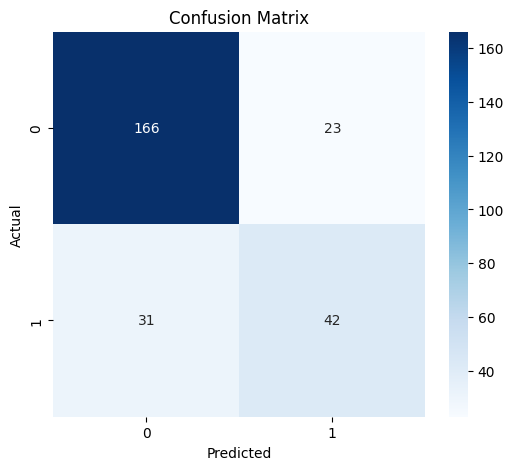

In [29]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

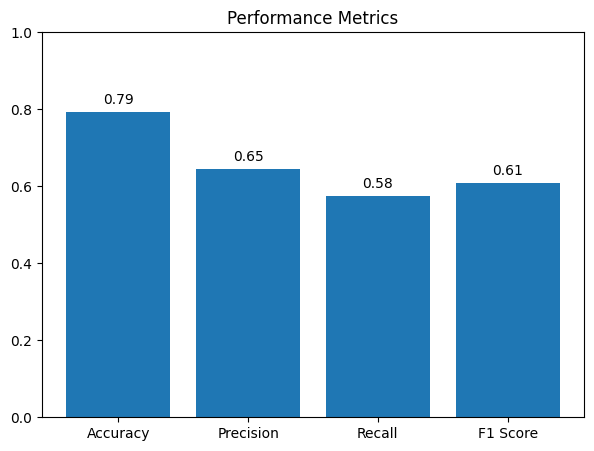

In [30]:
# Performance Metrics Chart

metrics = ["Accuracy","Precision","Recall","F1 Score"]

values = [accuracy,precision,recall,f1]

plt.figure(figsize=(7,5))

plt.bar(metrics,values)

plt.ylim(0,1)

plt.title("Performance Metrics")

for i,v in enumerate(values):
    plt.text(i,v+0.02,f"{v:.2f}",ha="center")

plt.show()